# Attribute 2 - Connectivity, Corridors & Stepping Stones

### Data layers
Existing natural areas


In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import json
import math
import os
from os import listdir

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from constants import (
    keep_cols,
    keep_cols_catch,
    m2_to_ha,
    small_polygon_threshold,
    x_resolution,
    y_resolution,
)

# Load

In [5]:
%%time
# Area of Interest
aoi = gpd.read_file(
    "../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg"
)
aoi = aoi[["Catchment", "geometry"]].copy()
aoi.sindex
aoi.shape

CPU times: total: 922 ms
Wall time: 1.53 s


(29431, 2)

In [26]:
%%time
# lcs = gpd.read_file("../BaseLayersEco-index/Eco-index_LandCoverSnapshot__Catchments_v290824.gpkg")
# restorable = gpd.read_file("../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg")
# restorable = restorable.overlay(lcs)

restorable = gpd.read_file(
    "../BaseLayersEco-index/Eco-index_RestorableAreas__Realms_v290824.gpkg"
)
restorable

CPU times: total: 1.16 s
Wall time: 1.17 s


,Catchment,EcosystemType,Realm,geometry
0,Ākitio,Marsh,Freshwater Wetland,"MULTIPOLYGON (((1873170.019 5527977.659, 18731..."
1,Ākitio,Marsh,Freshwater Wetland,"MULTIPOLYGON (((1878844.092 5521661.885, 18788..."
2,Ākitio,Marsh,Freshwater Wetland,"MULTIPOLYGON (((1881435.928 5517397.633, 18814..."
3,Ākitio,Mātai-tōtara-kahikatea-rimu/broadleaf-fuchsia ...,Terrestrial,"MULTIPOLYGON (((1870230.507 5524766.087, 18702..."
4,Ākitio,Mātai-tōtara-kahikatea-rimu/broadleaf-fuchsia ...,Terrestrial,"MULTIPOLYGON (((1860801.998 5509889.697, 18608..."
...,...,...,...,...
45984,Whangārei,Rimu/tawa-kamahi forest,Terrestrial,"MULTIPOLYGON (((1737915.749 6031185.026, 17378..."
45985,Whangārei,Rimu/tawa-kamahi forest,Terrestrial,"MULTIPOLYGON (((1739581.714 6046038.686, 17394..."
45986,Whangārei islands,Kauri/taraire-kohekohe-tawa forest,Terrestrial,"MULTIPOLYGON (((1790928.579 6024430.994, 17909..."
45987,Whangārei islands,Kauri/taraire-kohekohe-tawa forest,Terrestrial,"MULTIPOLYGON (((1790212.522 6024574.434, 17902..."


In [20]:
%%time
catch = gpd.read_file("../BaseLayersEco-index/Eco-index_Catchments_v080623.gpkg")
catch = catch.to_crs("epsg:2193")
catch.sindex

CPU times: total: 109 ms
Wall time: 443 ms


In [14]:
%%time
# ana = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot__Catchments_v290824.gpkg')
# ana = ana[ana.Realm.isin(['Freshwater', 'Terrestrial'])]
# ana = ana.dissolve(['Realm', 'Catchment'])
# ana = ana.reset_index()[['Realm', 'Catchment', 'geometry']].copy()
# ana.explode().to_file('../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/ana_realms_20240908.gpkg')
ana = gpd.read_file(
    "../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/ana_realms_20240908.gpkg"
)
ana.sindex
ana.shape

CPU times: total: 1.58 s
Wall time: 2.07 s


(140820, 3)

# Generate Stepping Stones

In [16]:
import time

from gis_analysis_functions import (
    expand_stepping_stone_until_size_with_overlay,
    generate_stepping_stones,
    priority_stack_n_layers,
    rasterize_and_save,
)

In [21]:
restorable = restorable.overlay(catch)

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 3513 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


In [23]:
restorable.to_file(
    "../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg"
)

In [25]:
restorable

,EcosystemType,PNVW,eco_index_,Shape_Leng,Shape_Area,Catchment,geometry
0,Inland saline,Inland saline,Clutha,1.416455e+06,2.110861e+10,Clutha,"MULTIPOLYGON (((1282712.954 4986175.107, 12826..."
1,Inland saline,Inland saline,Clutha,1.416455e+06,2.110861e+10,Clutha,"MULTIPOLYGON (((1322601.099 4975295.221, 13225..."
2,Inland saline,Inland saline,Taieri,8.034161e+05,7.985395e+09,Taieri,"MULTIPOLYGON (((1360676.293 4974055.952, 13606..."
3,Mātai-tōtara/black/mountain beech forest,Matai-totara/black/mountain beech forest,Aparima,4.651060e+05,2.063993e+09,Aparima,"MULTIPOLYGON (((1216063.666 4922152.674, 12160..."
4,Mātai-tōtara/black/mountain beech forest,Matai-totara/black/mountain beech forest,Aparima,4.651060e+05,2.063993e+09,Aparima,"MULTIPOLYGON (((1218894.671 4924233.64, 121874..."
...,...,...,...,...,...,...,...
45984,Rimu/tawa-kamahi forest,Rimu/tawa-kamahi forest,East_Cape,5.974903e+05,3.547110e+09,East-Cape,"POLYGON ((2065874.521 5827951.77, 2065845.417 ..."
45985,Rimu/tawa-kamahi forest,Rimu/tawa-kamahi forest,East_Cape,5.974903e+05,3.547110e+09,East-Cape,"MULTIPOLYGON (((2067121.064 5828443.812, 20671..."
45986,Rimu/tawa-kamahi forest,Rimu/tawa-kamahi forest,East_Cape,5.974903e+05,3.547110e+09,East-Cape,"POLYGON ((2065016.056 5828740.296, 2065016.399..."
45987,Rimu/tawa-kamahi forest,Rimu/tawa-kamahi forest,East_Cape,5.974903e+05,3.547110e+09,East-Cape,"MULTIPOLYGON (((2063194.103 5831195.777, 20631..."


In [42]:
aoi

,Catchment,geometry
0,Ākitio,"MULTIPOLYGON (((1883111.448 5491024.784, 18830..."
1,Ākitio,"MULTIPOLYGON (((1858596.338 5504134.83, 185858..."
2,Ākitio,"MULTIPOLYGON (((1858755.994 5504543.335, 18587..."
3,Ākitio,"MULTIPOLYGON (((1862109.44 5495777.024, 186210..."
4,Ākitio,"MULTIPOLYGON (((1863786.502 5498073.424, 18637..."
...,...,...
29426,Whangārei,"MULTIPOLYGON (((1738921.288 6056115.2, 1738921..."
29427,Whangārei,"MULTIPOLYGON (((1742640.725 6030936.683, 17426..."
29428,Whangārei islands,"MULTIPOLYGON (((1790928.579 6024430.994, 17909..."
29429,Whangārei islands,"MULTIPOLYGON (((1790212.522 6024574.434, 17902..."


In [43]:
ha_threshold = 100
small_min_size = 1
large_min_size = 5
small_ss_distance, small_ss_width = 900, 200
large_ss_distance, large_ss_width = 4900, 200

empty = gpd.GeoDataFrame({"geometry": pd.Series(dtype="geometry")}, crs="epsg:2193")

catch_layers = []

ana["area_ha"] = ana.area * m2_to_ha
ana = ana[ana.area_ha > 1]  # per meurk protocol

for n_catch, catchment in enumerate(aoi.Catchment.sort_values().unique()):
    # for n_catch, catchment in enumerate(['Ruamahanga']):

    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))
    print(f"\n{catchment.upper()}\n{current_time}")

    # First get the restorable area in this catchment
    sub_aoi = aoi[aoi.Catchment == catchment].copy()
    sub_aoi.sindex

    # We are only intersted in existing natural areas that are close to this restorable area
    # So sub_ana is all existing areas within 6000m of an existing natural areas
    sub_aoi_buff = sub_aoi.copy()
    sub_aoi_buff["geometry"] = sub_aoi_buff.buffer(6000)
    print("    buffering")
    sub_aoi_buff.sindex
    print("    overlaying")
    sub_ana = ana.overlay(sub_aoi_buff)

    realm = "Terrestrial"  ####################################################################################
    print(f"generating {realm} stepping stones ")

    # We then get the restorable area for this catchment and realm
    # This is the allowed enveloped where we can put stepping stones
    envelope = restorable[
        (restorable.Catchment == catchment) & (restorable.Realm == realm)
    ].copy()

    # Finally we get the actual existing areas of this realm, in the wider area
    # These are the areas we are trying to connect with stepping stones
    layers_to_stack = []
    terr = sub_ana[sub_ana.Realm == "Terrestrial"].copy()

    terr_step = generate_stepping_stones(
        terr, envelope, small_ss_distance, small_ss_width, min_size_ha=small_min_size
    )
    if terr_step is not None:
        terr_step["PixelDesc"] = (
            "Stepping stone between 900-1100 m of multiple Existing Natural Terrestrial Areas"
        )
        terr_step["PixelScore"] = 2
        terr_step["Attribute"] = "Connectivity Stepping Stones"
        layers_to_stack.append(terr_step)
        # terr_step.to_file(f'../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/{catchment}_{realm}_small.gpkg')

    terr_step_large = generate_stepping_stones(
        terr, envelope, large_ss_distance, large_ss_width, min_size_ha=large_min_size
    )
    if terr_step_large is not None:
        terr_step_large["PixelDesc"] = (
            "Stepping stone between 4900-5100 m of multiple Existing Natural Terrestrial Areas"
        )
        terr_step_large["PixelScore"] = 2
        terr_step_large["Attribute"] = "Connectivity Stepping Stones"
        layers_to_stack.append(terr_step_large)
        # terr_step_large.to_file(f'../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/{catchment}_{realm}_large.gpkg')

    if len(layers_to_stack) == 1:
        stacked = layers_to_stack[0]
    elif len(layers_to_stack) == 2:
        stacked = priority_stack_n_layers(layers_to_stack)

    elif len(layers_to_stack) == 0:
        print("no layers to stack")
        stacked = None

    terr.to_file(
        f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/{catchment}_{realm}_ana.gpkg"
    )
    envelope.to_file(
        f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/{catchment}_{realm}_envelope.gpkg"
    )
    realm = "Freshwater"  ####################################################################################
    print(f"generating {realm} stepping stones ")

    # We then get the restorable area for this catchment and realm
    # This is the allowed enveloped where we can put stepping stones
    envelope = restorable[
        (restorable.Catchment == catchment) & (restorable.Realm == realm)
    ].copy()

    # Finally we get the actual existing areas of this realm, in the wider area
    # These are the areas we are trying to connect with stepping stones
    layers_to_stack = []
    fre = sub_ana[sub_ana.Realm == "Freshwater"].copy()
    fre_step = generate_stepping_stones(
        fre, envelope, small_ss_distance, small_ss_width, min_size_ha=small_min_size
    )
    fre_step_large = generate_stepping_stones(
        fre, envelope, large_ss_distance, large_ss_width, min_size_ha=large_min_size
    )
    if fre_step_large is not None:
        fre_step_large["PixelDesc"] = (
            "Stepping stone between 4900-5100 m of multiple Existing Natural Freshwater Areas"
        )
        fre_step_large["PixelScore"] = 2
        fre_step_large["Attribute"] = "Connectivity Stepping Stones"
        layers_to_stack.append(fre_step_large)
    if fre_step is not None:
        fre_step["PixelDesc"] = (
            "Stepping stone between 900-1100 m of multiple Existing Natural Freshwater Areas"
        )
        fre_step["PixelScore"] = 2
        fre_step["Attribute"] = "Connectivity Stepping Stones"
        layers_to_stack.append(fre_step)
    if len(layers_to_stack) == 1:
        fre_stacked = layers_to_stack[0]
    elif len(layers_to_stack) == 2:
        fre_stacked = priority_stack_n_layers(layers_to_stack)
        print("fre_stacked shape: ", fre_stacked)
    elif len(layers_to_stack) == 0:
        print("no layers to stack")
        fre_stacked = None

    ####################################################################################

    if stacked is None and fre_stacked is not None:
        comb = fre_stacked.copy()
    elif stacked is not None and fre_stacked is None:
        comb = stacked.copy()
    elif stacked is not None and fre_stacked is not None:
        comb = priority_stack_n_layers([stacked_fre, stacked])
    else:
        # Nothing to save, continue
        continue

    catch_layers.append(comb)
    comb.to_file(
        f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/stacked_realms_{catchment}_29240725.gpkg"
    )


APARIMA
2024-09-16 14:31:29
    buffering
    overlaying
generating Terrestrial stepping stones 
needs expanding to meet min size: smallest_area = 150.73152213800603

Was:  150.73152213800603 10000.0 buffer_amunt =  10
Now:  3249.2739779149338 10000.0

Was:  3249.2739779149338 10000.0 buffer_amunt =  20
Now:  10047.107529533443 10000.0
Stepping stones have been cut off and are now below the min_area threshold: smallest_area_m2 = 275.1697039874605
Successfully expanded to target minimum amount of 1ha
needs expanding to meet min size: smallest_area = 40038.07629488749

Was:  40038.07629488749 50000.0 buffer_amunt =  10
Now:  57310.85325167345 50000.0
generating Freshwater stepping stones 
needs expanding to meet min size: smallest_area = 3172.790443860484

Was:  3172.790443860484 10000.0 buffer_amunt =  10
Now:  15597.354534601887 10000.0
needs expanding to meet min size: smallest_area = 40099.86950955807

Was:  40099.86950955807 50000.0 buffer_amunt =  10
Now:  57404.59973648342 50000.

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 1 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


Some areas couldn't be expanded and kept in the restoration envelope
No candidates found
generating Freshwater stepping stones 
needs expanding to meet min size: smallest_area = 158.49269206711205

Was:  158.49269206711205 10000.0 buffer_amunt =  10
Now:  5617.776366402668 10000.0

Was:  5617.776366402668 10000.0 buffer_amunt =  20
Now:  10007.813950710937 10000.0
needs expanding to meet min size: smallest_area = 40020.24532317771

Was:  40020.24532317771 50000.0 buffer_amunt =  10
Now:  50413.38154705312 50000.0
no layers to stack

MANGARĀKAU
2024-09-16 16:12:41
    buffering
    overlaying
generating Terrestrial stepping stones 
No expanding required to meet min size: smallest_area = 42444.0044840904
No candidates found
no layers to stack
generating Freshwater stepping stones 
No expanding required to meet min size: smallest_area = 39295.95428137097
No candidates found
no layers to stack

MANGAWHAI
2024-09-16 16:13:16
    buffering
    overlaying
generating Terrestrial stepping stone

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\shapely\set_operations.py:419: RuntimeWarning: divide by zero encountered in unary_union
  return lib.unary_union(collections, **kwargs)


needs expanding to meet min size: smallest_area = 0.9550030721230549

Was:  0.9550030721230549 10000.0 buffer_amunt =  10
Now:  1352.6516042736928 10000.0

Was:  1352.6516042736928 10000.0 buffer_amunt =  20
Now:  8089.71505690544 10000.0

Was:  8089.71505690544 10000.0 buffer_amunt =  30
Now:  10221.614414619158 10000.0
Stepping stones have been cut off and are now below the min_area threshold: smallest_area_m2 = 0.15616532354704304
Successfully expanded to target minimum amount of 1ha
No candidates found
generating Freshwater stepping stones 
needs expanding to meet min size: smallest_area = 69.91502187079884

Was:  69.91502187079884 10000.0 buffer_amunt =  10
Now:  4395.983048609077 10000.0

Was:  4395.983048609077 10000.0 buffer_amunt =  20
Now:  10075.538848326763 10000.0
needs expanding to meet min size: smallest_area = 878.8042111890323

Was:  878.8042111890323 50000.0 buffer_amunt =  10
Now:  5443.828907377692 50000.0

Was:  5443.828907377692 50000.0 buffer_amunt =  20
Now:  17

...

No expanding required to meet min size: smallest_area = 40133.917781782664
needs expanding to meet min size: smallest_area = 40010.56823325661

Was:  40010.56823325661 50000.0 buffer_amunt =  10
Now:  57276.54840471184 50000.0
no layers to stack

RANGITATA
2024-09-16 16:51:59
    buffering
    overlaying
generating Terrestrial stepping stones 
needs expanding to meet min size: smallest_area = 800.5478624160924

Was:  800.5478624160924 10000.0 buffer_amunt =  10
Now:  4933.508069457194 10000.0

Was:  4933.508069457194 10000.0 buffer_amunt =  20
Now:  15842.346470971572 10000.0
No changes required
needs expanding to meet min size: smallest_area = 41510.65436488801

Was:  41510.65436488801 50000.0 buffer_amunt =  10
Now:  59351.49765679022 50000.0
generating Freshwater stepping stones 


C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\shapely\set_operations.py:419: RuntimeWarning: divide by zero encountered in unary_union
  return lib.unary_union(collections, **kwargs)


needs expanding to meet min size: smallest_area = 155.18292761260955

Was:  155.18292761260955 10000.0 buffer_amunt =  10
Now:  4829.760197489094 10000.0

Was:  4829.760197489094 10000.0 buffer_amunt =  20
Now:  15593.90977147137 10000.0
needs expanding to meet min size: smallest_area = 40123.61513699525

Was:  40123.61513699525 50000.0 buffer_amunt =  10
Now:  55407.828383432636 50000.0
no layers to stack

RANGITĪKEI
2024-09-16 16:52:53
    buffering
    overlaying
generating Terrestrial stepping stones 
needs expanding to meet min size: smallest_area = 44.16204250925033

Was:  44.16204250925033 10000.0 buffer_amunt =  10
Now:  1910.59584815331 10000.0

Was:  1910.59584815331 10000.0 buffer_amunt =  20
Now:  9419.76737457101 10000.0

Was:  9419.76737457101 10000.0 buffer_amunt =  30
Now:  10118.958639940505 10000.0
Stepping stones have been cut off and are now below the min_area threshold: smallest_area_m2 = 0.883176789076751
Successfully expanded to target minimum amount of 1ha
No ca

C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(
C:\Users\dav\miniconda3_9\envs\eco\Lib\site-packages\geopandas\geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 2 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


Successfully expanded to target minimum amount of 1ha
needs expanding to meet min size: smallest_area = 40145.85400502962

Was:  40145.85400502962 50000.0 buffer_amunt =  10
Now:  57468.15108976618 50000.0
generating Freshwater stepping stones 
needs expanding to meet min size: smallest_area = 1837.006180281209

Was:  1837.006180281209 10000.0 buffer_amunt =  10
Now:  12358.09158706492 10000.0
needs expanding to meet min size: smallest_area = 40019.158648206714

Was:  40019.158648206714 50000.0 buffer_amunt =  10
Now:  55520.685062635916 50000.0
no layers to stack

WAIAU NORTH
2024-09-16 17:12:45
    buffering
    overlaying
generating Terrestrial stepping stones 
needs expanding to meet min size: smallest_area = 1996.8807832158404

Was:  1996.8807832158404 10000.0 buffer_amunt =  10
Now:  7813.560328279574 10000.0

Was:  7813.560328279574 10000.0 buffer_amunt =  20
Now:  12694.580782263127 10000.0
No changes required
No candidates found
generating Freshwater stepping stones 
needs exp

In [52]:
final = gpd.GeoDataFrame(pd.concat(catch_layers, ignore_index=True))

In [30]:
comb.to_file(
    f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/stacked_realms_{catchment}_29240725.gpkg"
)

In [679]:
if len(catch_layers) >= 1:
    final = priority_stack_n_layers(catch_layers)
elif len(catch_layers) == 1:
    final = catch_layers[0]
else:
    raise ValueError("No layers found")

In [99]:
import re
from pathlib import Path

folder_path = Path(
    "../OutputArtifacts/A02_ConnectivitySteppingStones/A02_IntermediateLayers/catchments/"
)
pattern = "stacked_realms_*_29240725.gpkg"
matched_files = sorted(folder_path.glob(pattern), key=lambda x: x.name)

# Sort the matched files alphabetically by their name
matched_files = sorted(folder_path.glob(pattern), key=lambda x: x.name)

# Initialize an empty list for the catchment names
catchment_names = []

# Define the regex pattern
regex = r"stacked_realms_(.+?)_29240725\.gpkg$"
gdfs = []
# Use a for loop to extract catchment names
for file_path in matched_files:
    match = re.match(regex, file_path.name)
    if match:
        catchment_name = match.group(1)
        catchment_names.append(catchment_name)
        gdf = gpd.read_file(file_path)
        gdf["Catchment"] = catchment_name
        gdf["PrioOption"] = "Connectivity Stepping Stones"
        gdf["Area_ha"] = gdf.area * m2_to_ha
        gdf = gdf[gdf.Area_ha > small_polygon_threshold].copy()
        gdf["Area_ha"] = gdf["Area_ha"].round(2)
        # gdf[keep_cols_catch].to_file(
            # f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_Catchments/A02_Connectivity_{catchment_name}_20240726.gpkg")
        gdfs.append(gdf)

In [103]:
# final = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
# final[keep_cols_catch].to_file(f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_Catchments/A02_Connectivity_20240916.gpkg")
final[keep_cols_catch]

,PrioOption,Catchment,PixelScore,PixelDesc,Area_ha,geometry
0,Connectivity Stepping Stones,Aparima,2,Stepping stone between 900-1100 m of multiple ...,4.06,"POLYGON ((1213852.639 4856626.611, 1213895.736..."
1,Connectivity Stepping Stones,Aparima,2,Stepping stone between 900-1100 m of multiple ...,7.76,"POLYGON ((1211399.976 4856531.152, 1211394.521..."
2,Connectivity Stepping Stones,Aparima,2,Stepping stone between 900-1100 m of multiple ...,4.33,"POLYGON ((1210020.673 4878437.299, 1210065.127..."
3,Connectivity Stepping Stones,Aparima,2,Stepping stone between 900-1100 m of multiple ...,3.58,"POLYGON ((1212616.059 4878551.687, 1212585.627..."
4,Connectivity Stepping Stones,Aparima,2,Stepping stone between 900-1100 m of multiple ...,4.02,"POLYGON ((1209833.998 4878814.014, 1209866.526..."
...,...,...,...,...,...,...
6094,Connectivity Stepping Stones,Ōtaki,2,Stepping stone between 900-1100 m of multiple ...,1.75,"MULTIPOLYGON (((1776663.215 5480093.765, 17766..."
6095,Connectivity Stepping Stones,Ōtaki,2,Stepping stone between 900-1100 m of multiple ...,2.41,"MULTIPOLYGON (((1778646.84 5480005.945, 177864..."
6096,Connectivity Stepping Stones,Ōtaki,2,Stepping stone between 900-1100 m of multiple ...,1.88,"MULTIPOLYGON (((1777417.641 5480412.678, 17773..."
6097,Connectivity Stepping Stones,Ōtaki,2,Stepping stone between 900-1100 m of multiple ...,2.14,"MULTIPOLYGON (((1781204.946 5485298.421, 17812..."


In [74]:
catch_layers[0].columns

Index(['Label', 'geometry', 'PixelDesc', 'PixelScore', 'Attribute'], dtype='object')

In [35]:
# # Shape
shape_path = f"../OutputArtifacts/A02_ConnectivitySteppingStones/A02_Connectivity_epsg2193_20240726.gpkg"
final["PrioOption"] = final["Attribute"].copy()
final[keep_cols].to_file(shape_path)

print(f"Completed saving shape file\n{current_time}")

Completed saving shape file
2024-09-16 13:14:15


In [688]:
gdf = gpd.read_file(
    r"C:\Users\dav\Documents\EcoIndex\_NAVIGATOR\Reconstruction_Heatmap_20240724_vectorised_4326.geojson"
)

In [691]:
gdf = gdf[gdf.DN > 0]
gdf.to_file(
    r"C:\Users\dav\Documents\EcoIndex\_NAVIGATOR\Reconstruction_Heatmap_20240724_vectorised_4326_no0.geojson"
)

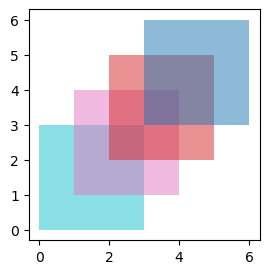

Subtracted layer 1
Subtracted layer 2
Subtracted layer 3


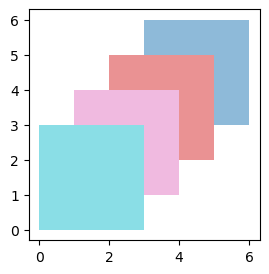

In [620]:
# Define 4 overlapping polygons
polygon1 = Polygon([(0, 0), (2, 0), (2, 2), (0, 2), (0, 0)])
polygon2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3), (1, 1)])
polygon3 = Polygon([(2, 2), (4, 2), (4, 4), (2, 4), (2, 2)])
polygon2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3), (1, 1)])

polygon4 = Polygon([(0, 2), (2, 2), (2, 4), (0, 4), (0, 2)])

# Define 4 overlapping polygons with the same size
size = 3
polygons = [
    Polygon([(i, i), (i + size, i), (i + size, i + size), (i, i + size), (i, i)])
    for i in range(4)
]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame({"geometry": polygons, "PixelScore": [10, 8, 6, 4]})

fig, ax = plt.subplots(figsize=(3, 3))
gdf.plot(
    ax=ax,
    column="PixelScore",
    categorical=True,
    alpha=0.5,
)
plt.show()


gdfs = [
    gdf[gdf.PixelScore == 10],
    gdf[gdf.PixelScore == 8],
    gdf[gdf.PixelScore == 6],
    gdf[gdf.PixelScore == 4],
]

gdf2 = priority_stack_n_layers(gdfs)
gdfs
fig, ax = plt.subplots(figsize=(3, 3))
gdf2.plot(
    ax=ax,
    column="PixelScore",
    categorical=True,
    alpha=0.5,
)
plt.show()

In [694]:
aoi.Catchment.unique()

array(['Hutt', 'Ruamahanga', 'Ōrongorongo-Wainuiomata'], dtype=object)

# Test Dissolve Overlapping

In [490]:
# Define complex polygons with multiple overlapping groups
polygons = [
    Polygon([(0, 0), (2, 0), (1, 3)]),  # Overlaps with the next two
    Polygon([(1, 0), (3, 0), (2, 2)]),
    Polygon([(0.5, 1), (2.5, 1), (1.5, 4)]),  # Also overlaps with the first two
    Polygon([(3.1, 0), (5, 0), (4, 3)]),  # Separate overlapping group
    Polygon([(4, 0), (6, 0), (5, 2)]),
    Polygon([(10, 0), (11, 0), (10.5, 1)]),  # Non-overlapping
    Polygon([(12, 0), (13, 0), (12.5, 1)]),  # Another non-overlapping
]
labels = ["A", "B", "C", "D", "E", "F", "G"]

from gis_analysis_functions import dissolve_overlapping

gdf = gpd.GeoDataFrame({"geometry": polygons, "Label": labels})
gdf2 = dissolve_overlapping(gdf, id_col="Label")
gdf2

,Label,geometry
0,"A, B, C","POLYGON ((1 0, 0 0, 1 3, 1.08333 2.75, 1.5 4, ..."
1,"D, E","POLYGON ((4 0, 3.1 0, 4 3, 4.6 1.2, 5 2, 6 0, ..."
2,F,"POLYGON ((10 0, 11 0, 10.5 1, 10 0))"
3,G,"POLYGON ((12 0, 13 0, 12.5 1, 12 0))"


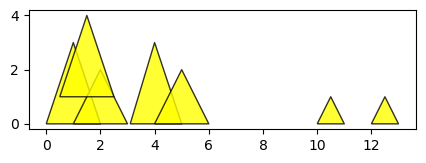

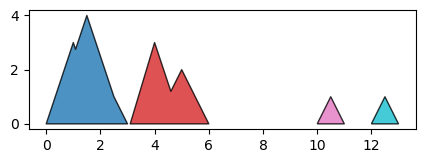

In [487]:
fig, ax = plt.subplots(figsize=(5, 5))
gdf.plot(ax=ax, alpha=0.8, color="yellow", edgecolor="black")
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
gdf2.plot(ax=ax, alpha=0.8, column="Label", edgecolor="black")
plt.show()

In [606]:
terr_sse_candidates

,id_x,Realm_x,Catchment_1_x,area_ha_x,Catchment_2_x,geometry_x,id_y,Realm_y,Catchment_1_y,area_ha_y,Catchment_2_y,geometry_y,inter,geometry
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1782707.255 5412276.153, 1782747.793...","POLYGON ((1782707.255 5412276.153, 1782747.793..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1782703.69 5414251.754, 1782711.045 ...","POLYGON ((1782703.69 5414251.754, 1782711.045 ..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1779669.167 5416038.853, 1779678.437...","POLYGON ((1779669.167 5416038.853, 1779678.437..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1781799.804 5418575.355, 1781825.559...","POLYGON ((1781799.804 5418575.355, 1781825.559..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1781599.238 5420095.193, 1781607.106...","POLYGON ((1781599.238 5420095.193, 1781607.106..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1834504.025 5481435.597, 1834488.049...","POLYGON ((1834504.025 5481435.597, 1834488.049..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1832022.3 5483722.935, 1832023.122 5...","POLYGON ((1832022.3 5483722.935, 1832023.122 5..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1832445.147 5483658.986, 1832423.685...","POLYGON ((1832445.147 5483658.986, 1832423.685..."
0,0,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1782226.399 5418320.542, 1782225.72 ...",1,Terrestrial,Hutt,44354.704521,Ruamahanga,"POLYGON ((1766998.421 5416620.466, 1766996.864...","POLYGON ((1831983.29 5483968.622, 1831994.497 ...","POLYGON ((1831983.29 5483968.622, 1831994.497 ..."


In [608]:
terr_sse_candidates[["geometry"]].overlay(envelope).to_file(
    "output_layers/attr02/terr_sse_candidates.gpkg"
)
terr_sse_candidates_filt.to_file("output_layers/attr02/terr_sse_candidates_filt.gpkg")

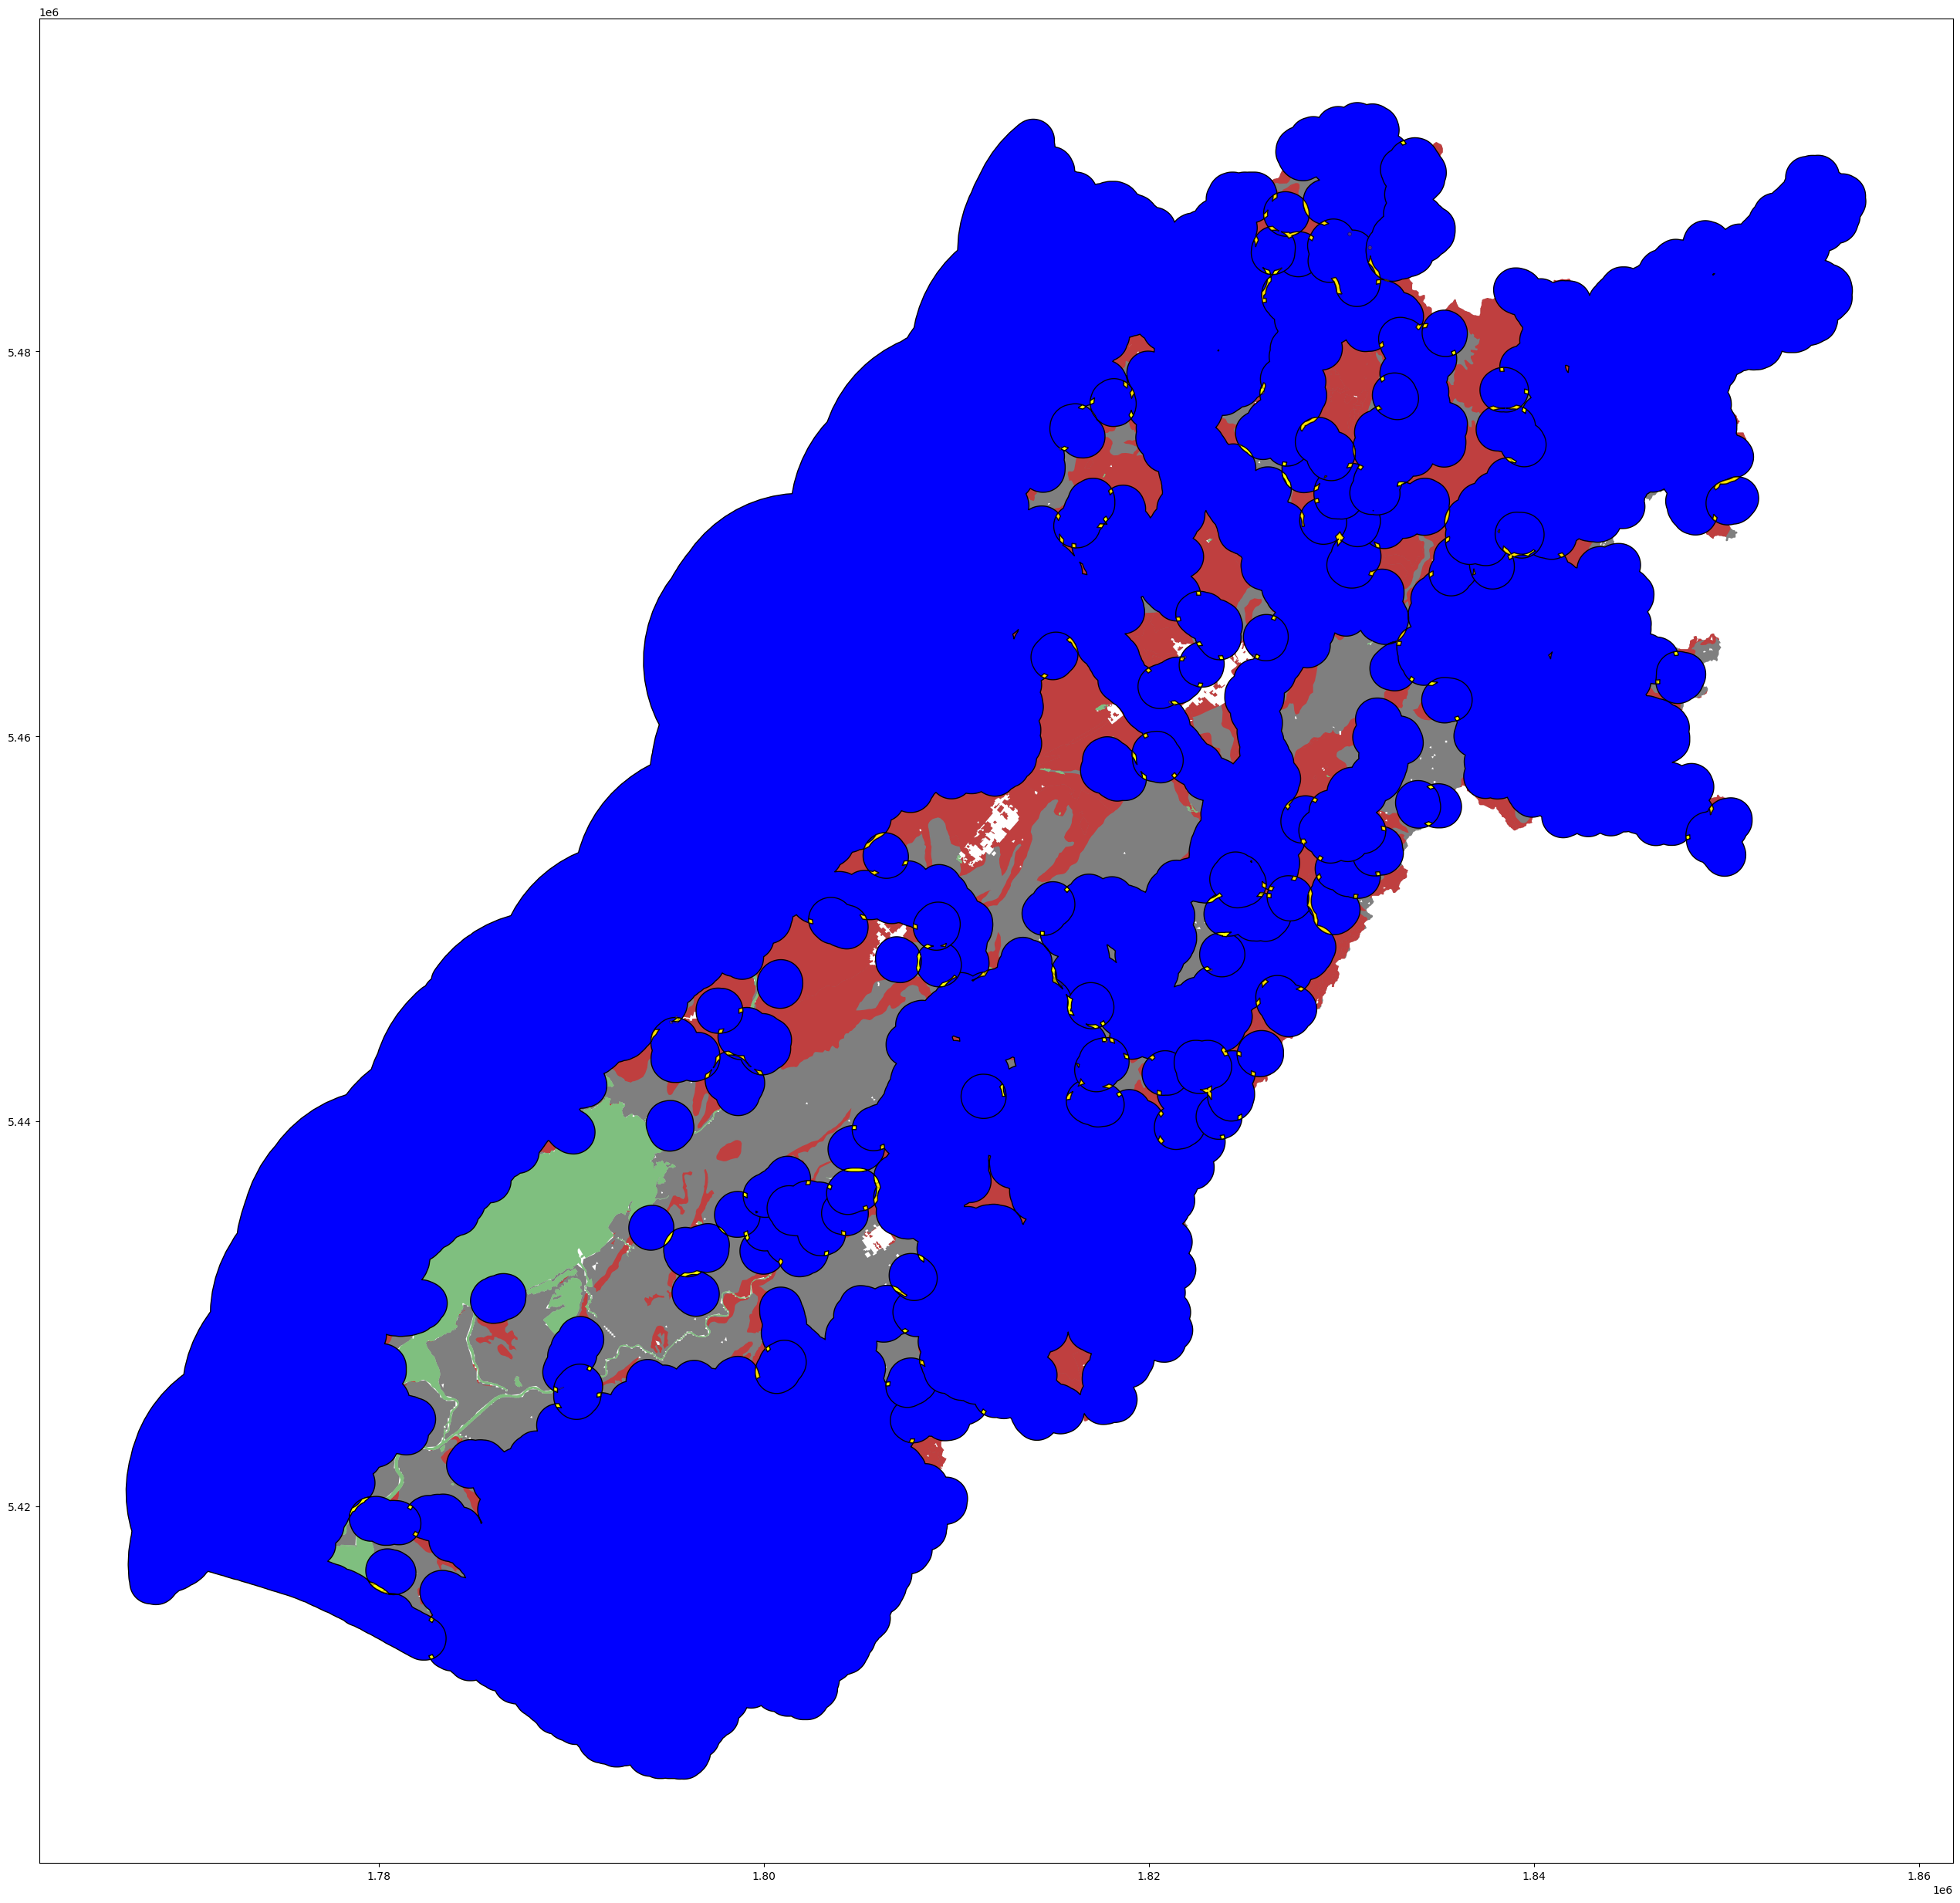

In [604]:
fig, ax = plt.subplots(figsize=(32, 32))
sub_aoi.plot(ax=ax, alpha=0.5, color="black")
# sub_aoi_buff.plot(ax=ax, alpha=0.5, color="red")
envelope.plot(ax=ax, alpha=0.5, color="red")
sub_ana.plot(ax=ax, alpha=0.5, color="green")
terr.plot(ax=ax, alpha=0.5, color="blue")
# terr_buffer_half.plot(ax=ax, alpha=1, color="blue")
# terr_buffer_indv.plot(ax=ax, alpha=1, color="blue")
terr_buffer_200.plot(ax=ax, alpha=1, color="blue", edgecolor="black")
terr_sse_candidates.plot(ax=ax, alpha=1, color="yellow", edgecolor="black")
terr_sse_candidates_filt.plot(ax=ax, alpha=0.3, color="orange", edgecolor="black")
plt.show()

In [64]:
import plotly.express as px

In [65]:
# Plotting terr_donut_large
fig_donut = px.choropleth_mapbox(
    terr_donut,
    geojson=terr_donut.geometry.__geo_interface__,
    locations=terr_donut.index,
    color="PixelScore",  # Replace with the column you want to color by
    center={
        "lat": terr_donut_large.geometry.centroid.y.mean(),
        "lon": terr_donut_large.geometry.centroid.x.mean(),
    },
    mapbox_style="open-street-map",
    zoom=5,
)

fig_donut.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig_donut.show()

# Plotting terr_step_large_raw similarly
fig_step = px.choropleth_mapbox(
    terr_step,
    geojson=terr_step.geometry.__geo_interface__,
    locations=terr_step.index,
    color="PixelScore",  # Replace with the column you want to color by
    center={
        "lat": terr_step_large_raw.geometry.centroid.y.mean(),
        "lon": terr_step_large_raw.geometry.centroid.x.mean(),
    },
    mapbox_style="open-street-map",
    zoom=5,
)

fig_step.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig_step.show()

AttributeError: 'NoneType' object has no attribute 'geometry'

In [62]:
terr

,Realm,Catchment_1,Catchment_2,area_ha,geometry
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1755039.79 5419134.007, 1755028.787 ..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1754967.692 5419300.649, 1754967.692..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1754906.059 5419844.202, 1754906.059..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1754879.078 5420000.259, 1754878.944..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1754938.971 5420195.804, 1754940.222..."
...,...,...,...,...,...
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1787296.56 5451972.298, 1787264.944 ..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1787107.954 5451979.929, 1787104.126..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1786714.841 5452030.947, 1786722.019..."
0,Terrestrial,Hutt,Hutt,3.299326e-07,"POLYGON ((1786836.491 5452060.605, 1786812.506..."


# Save Vector and Rasterize

In [8]:
%%time
from gis_analysis_functions import rasterize_and_save

# output_file_path = "output_layers/attr02/02_Connectivity_Stepping_Stones_10m_20240527_dairy.tif"
# rasterize_and_save(trz, gdf_dairy, 10, 10, output_file_path)
# current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(time.time()))
# print(f'Completed raster \n{current_time}')

CPU times: total: 15.6 ms
Wall time: 12.9 ms


In [9]:
# %%time
# status = gpd.read_file('base_layers/eco-index-current-status-and-restoration-priority-for-nz.gpkg')
# status = status.to_crs('epsg:2193')
# status.sindex
# status.shape

# status_raw = status.copy()

In [11]:
# tot_pnvw = pd.read_csv(
#     "TABLE OF TRUTH_Mapping LCDB and PNVW to realms and land status.xlsx - PNVW mapping.csv"
# )

# tot_pnvw = tot_pnvw[
#     [
#         "Potential Natural Vegetation and Wetland Type",
#         "Eco_index Realm (not same as Costanza or IUCN)",
#     ]
# ].copy()

# tot_pnvw = tot_pnvw.rename(
#     {
#         "Potential Natural Vegetation and Wetland Type": "PNVWmacron",
#         "Eco_index Realm (not same as Costanza or IUCN)": "Realm",
#     },
#     axis=1,
# )
# tot_pnvw = tot_pnvw.append(
#     pd.DataFrame(
#         {
#             "PNVWmacron": [
#                 "Unclassified",
#                 "unclassified",
#                 "Hall's tōtara-miro/kāmahi-southern rata broadleaf forest",
#                 "Hall's totara-miro/kamahi-southern rata broadleaf forest",
#             ],
#             "Realm": ["unclassified", "unclassified", "Terrestrial", "Terrestrial"],
#         }
#     )
# )
# tot_pnvw["PNVWmacron"] = tot_pnvw.PNVWmacron.str.replace("_", " ")

# # #Merge onto Status layer
# # statusr = status.merge(tot_pnvw, on='PNVWmacron', how='left')
# # assert status.shape[0] == statusr.shape[0]
# # status = statusr.copy()
# # restorable = status[status.RestStat18=='Potentially restorable']
# # del statusr


# # trz2 = trz.merge(tot_pnvw, on='PNVWmacron', how='left')
# # assert trz.shape[0] == trz2.shape[0]
# # trz2[trz2.Realm.isna()].PNVWmacron.unique()
# # trz = trz2.copy()
# # del trz2

In [12]:
# %%time

# catchment='Aparima'
# # Do convex hull & remove any results too large
# sub_catch = catch[catch.Catchment == catchment].copy()
# sub_catch['geometry'] = sub_catch.buffer(6000)
# sub_ana = ana.overlay(sub_catch)

# terr = sub_ana.copy()
# terr = terr[terr.Realm == 'Terrestrial']

# fre = sub_ana.copy()
# fre = fre[fre.Realm == 'Freshwater']

# # Generate the stepping stones and donuts for each realm
# sub_trz = trz[(trz.Catchment==catchment) &
#                     (trz.Realm == 'Terrestrial')].copy()

# diff = generate_stepping_stones(terr, sub_trz, realm_name='Terrestrial', first_buffer_size=900, second_buffer_size=200)
# diff = diff.overlay(trz[trz.Catchment==catchment], how='intersection')
# final = diff.overlay(restorable, how='intersection')

# fig, ax = plt.subplots(figsize=(12,12))
# sub_trz.plot(ax=ax, color='yellow', alpha=.5)
# diff[diff.PixelScore==4].plot(ax=ax, color='black', alpha=1,)
# diff[diff.PixelScore==2].plot(ax=ax, color='red', alpha=.5)
# # final.plot(ax=ax, color='blue')
# plt.show()
# diff.drop_duplicates('PixelDesc').head()

## TODO: NOTE
This approach of using TRZ to ensure stepping stones are in a valid restorable area of the correct realm only works for the heatmap - not for the general connectivity layer!!

CPU times: total: 0 ns
Wall time: 0 ns



HUTT
2024-07-22 21:02:57
generating TER stepping stones


<timed exec>:16: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:26: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:63: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
C:\Users\dav\.pyenv\pyenv-win\versions\3.9.13\li

12


<timed exec>:16: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:26: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.


IndexError: single positional indexer is out-of-bounds

In [25]:
terr_step_raw.reset_index().crs

AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

In [19]:
terr_step_raw = terr_step_raw.overlay(sub_ana[["geometry"]], how="intersection")

AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

In [24]:
#     # Stacking different layers:
#     terr_donut, terr_low_scorers = (terr_sse[terr_sse['PixelScore'] ==4],
#                                            terr_sse[terr_sse['PixelScore'] ==2])
#     terr_large_high_scorers, terr_large_low_scorers = (terr_sse_large[terr_sse_large['PixelScore'] ==4],
#                                                         terr_sse_large[terr_sse_large['PixelScore'] ==2])

#     fre_high_scorers, fre_low_scorers = (fre_sse[fre_sse['PixelScore'] ==4],
#                                            fre_sse[fre_sse['PixelScore'] ==2])
#     fre_large_high_scorers, fre_large_low_scorers = (fre_sse_large[fre_sse_large['PixelScore'] ==4],
#                                                         fre_sse_large[fre_sse_large['PixelScore'] ==2])


# unstacked_layers = [i for i in [terr_step_large, fre_step_large,
#                                 terr_step, fre_step,
#                                 terr_donut_large, fre_donut_large,
#                                 terr_donut, fre_donut] if i.shape[0] > 0]

# stacked_layers = priority_stack_n_layers(unstacked_layers)
# stacked_layers.to_file(
#     f"wip_layers/attr02/{str(n_catch).zfill(3)}_{catchment}_stepping_stones.gpkg"
# )
# # sub_ana.to_file(
# #     f"wip_layers/attr02_ena_catchment/{str(n_catch).zfill(3)}_{catchment}_ena_realm.gpkg"
# # )
# # print(f'\n{catchment.upper()}\n{current_time}')
# break

## Quick test of priority stacking

In [10]:
# from shapely.geometry import Polygon

# def priority_stack_n_layers(layers_desc_prio, geometry_col='geometry'):
#     """
#     Stack a n layers, such that one layer of higher priority is 'on top' and unchanged,
#     and sucessive layers are below and cropped so there's no overlapping polygons
#     """

#     stacked_layers = []

#     # Start from Highest Priority:
#     # Needs no change as this sits on top
#     combined_layer = layers_desc_prio[0].copy()

#     for n_layer, layer in enumerate(layers_desc_prio[1:]):
#         # subtract the layer on top
#         next_layer = layer.overlay(combined_layer, how='difference')
#         print(f'Subtracted layer {n_layer+1}')

#         combined_layer = gpd.GeoDataFrame(pd.concat([combined_layer,next_layer], axis=0, ignore_index=True))
#     return combined_layer


# # Define 4 overlapping polygons
# polygon1 = Polygon([(0, 0), (2, 0), (2, 2), (0, 2), (0, 0)])
# polygon2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3), (1, 1)])
# polygon3 = Polygon([(2, 2), (4, 2), (4, 4), (2, 4), (2, 2)])
# polygon2 = Polygon([(1, 1), (3, 1), (3, 3), (1, 3), (1, 1)])

# polygon4 = Polygon([(0, 2), (2, 2), (2, 4), (0, 4), (0, 2)])

# # Define 4 overlapping polygons with the same size
# size = 3
# polygons = [
#     Polygon([(i, i), (i + size, i), (i + size, i + size), (i, i + size), (i, i)])
#     for i in range(4)
# ]

# # Create a GeoDataFrame
# gdf = gpd.GeoDataFrame({'geometry': polygons, 'PixelScore':[10,8,6,4]})

# fig, ax = plt.subplots(figsize=(6,6))
# gdf.plot(ax=ax, column='PixelScore', categorical=True, alpha=.5,)
# plt.show()


# gdfs = [gdf[gdf.PixelScore==10],
# gdf[gdf.PixelScore==8],
# gdf[gdf.PixelScore==6],
# gdf[gdf.PixelScore==4],]

# gdf2 = priority_stack_n_layers(gdfs)
# gdfs
# fig, ax = plt.subplots(figsize=(6,6))
# gdf2.plot(ax=ax, column='PixelScore', categorical=True, alpha=.5,)
# plt.show()


APARIMA
2024-05-22 07:25:49
generating TER stepping stones


<timed exec>:16: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:26: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:63: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
C:\Users\dav\.pyenv\pyenv-win\versions\3.9.13\li

generating terr stepping stones


<timed exec>:16: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:26: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:34: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
<timed exec>:63: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.


AttributeError: The CRS attribute of a GeoDataFrame without an active geometry column is not defined. Use GeoDataFrame.set_geometry to set the active geometry column.

In [ ]:
# Function to load and concatenate all Shapefiles in a directory
def load_and_concat_saved(directory, extension="shp"):
    # List to hold individual GeoDataFrames
    gdfs = []

    # Iterate through all files in the directory
    for file in os.listdir(directory):
        if file.endswith(f".{extension}"):
            filepath = os.path.join(directory, file)
            try:
                # Load the Shapefile into a GeoDataFrame
                gdf = gpd.read_file(filepath)
                gdfs.append(gdf)
                print(f"Loaded {file} successfully.")
            except Exception as e:
                print(f"Error loading {file}: {e}")

    # Concatenate all GeoDataFrames
    if gdfs:
        concatenated_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
        print("Concatenation complete.")
        return concatenated_gdf
    else:
        print("No Shapefiles found in the directory.")
        return None


concatenated_gdf = load_and_concat_saved(
    "output_layers/attr03/attr03_by_catchment", extension="gpkg"
)
concatenated_gdf_dairy = load_and_concat_saved(
    "output_layers/attr03/attr03_by_catchment_dairy", extension="gpkg"
)

In [ ]:
#     unstacked_layers = [i for i in [terr_large_high_scorers, fre_large_high_scorers,
#                             terr_high_scorers, fre_high_scorers,
#                             terr_large_low_scorers, fre_large_low_scorers,
#                             terr_low_scorers, fre_low_scorers]
#                        if i.shape[0] > 0]

#     stacked_layers = priority_stack_n_layers(unstacked_layers)

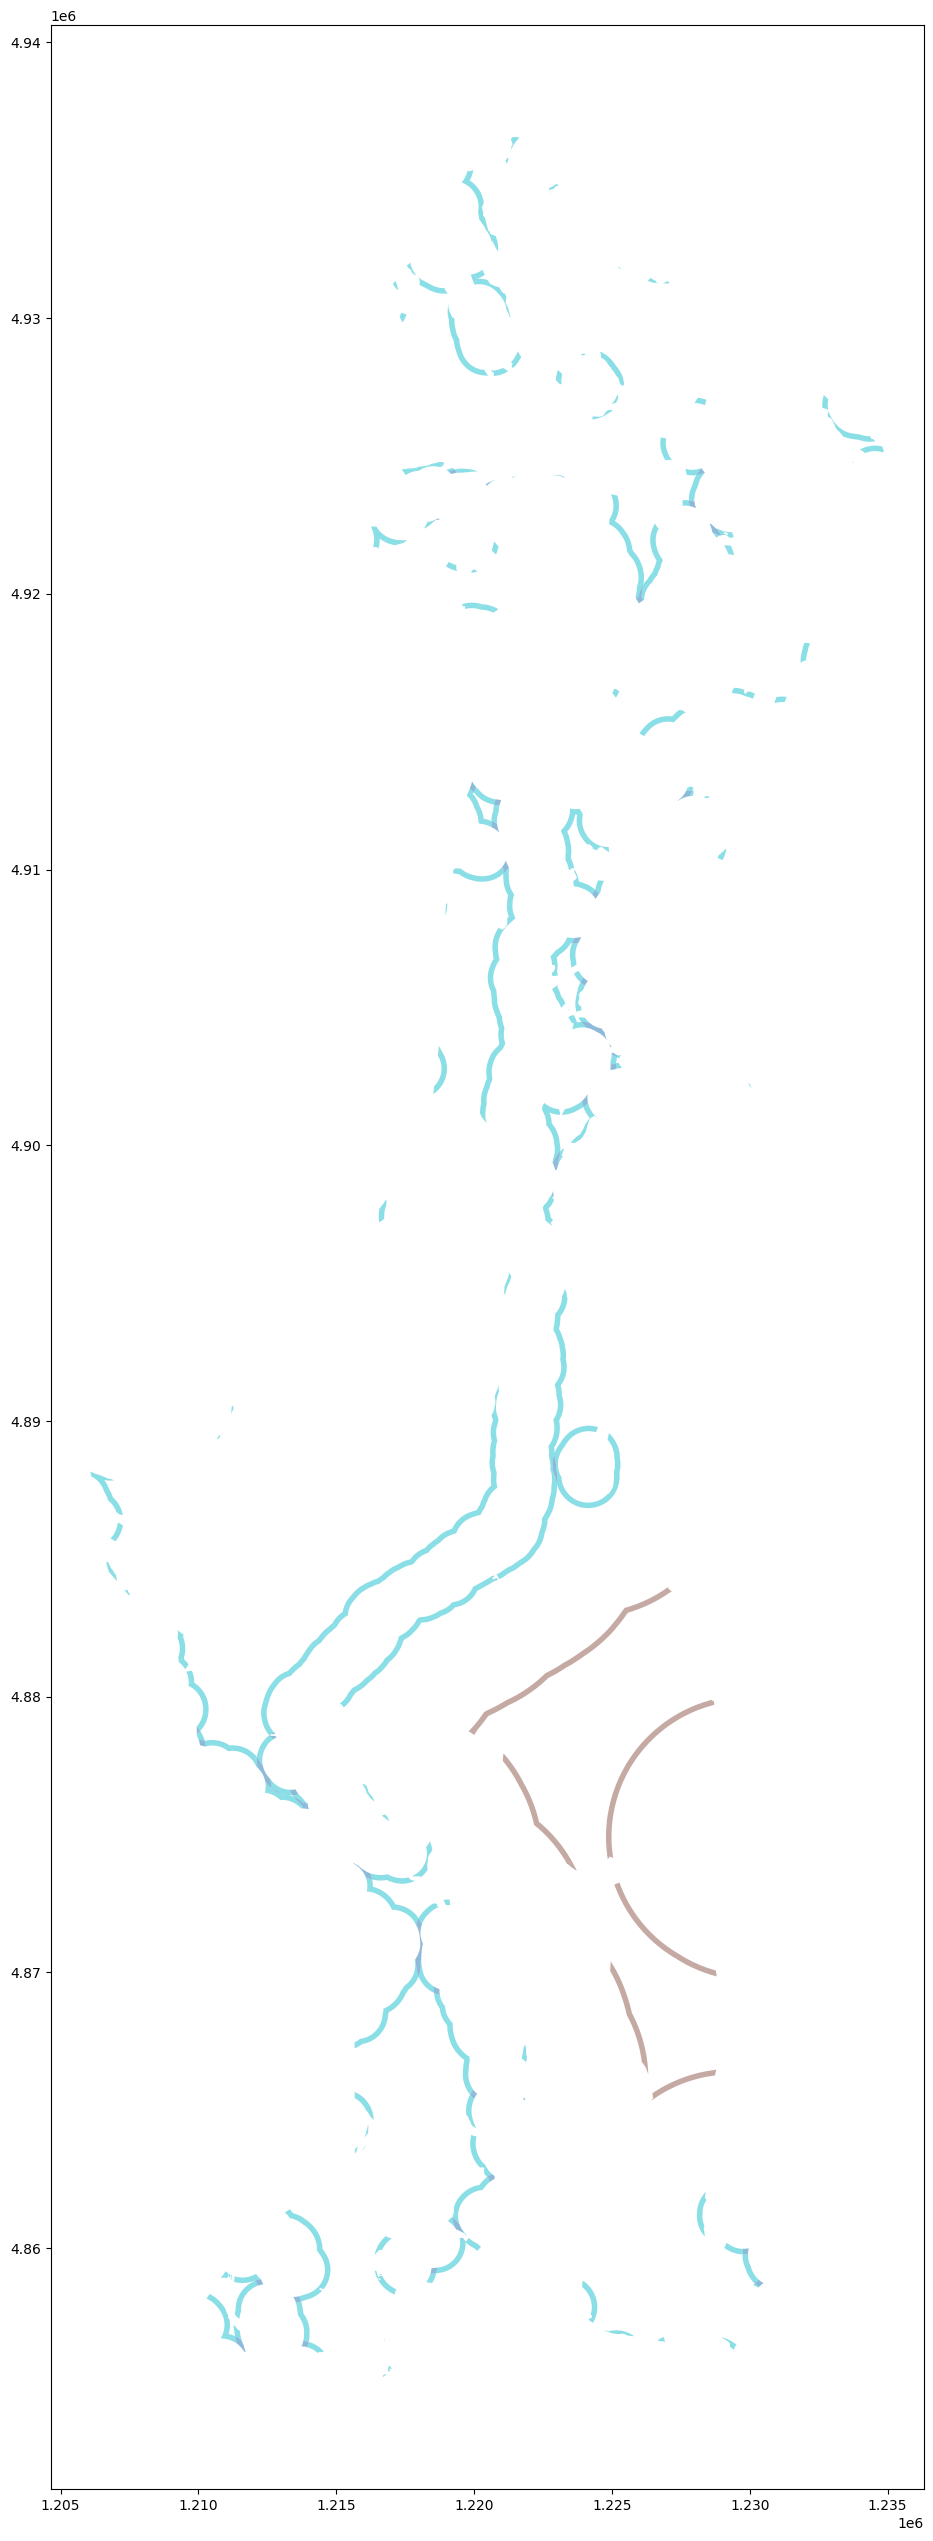

In [64]:
fig, ax = plt.subplots(figsize=(32, 32))
stacked_layers.plot(
    ax=ax,
    column="PixelDesc",
    categorical=True,
    alpha=0.5,
)
plt.show()

### Generate the stepping stones for:
- For both close stepping stones 900-1100m, and larger further stepping stones 4850-5150m
- For both freshwater wetland and terrrestrial realms

In [6]:
# %%time
# terr_buffer_half, terr_buffer_indv, terr_buffer_200, terr_sse_candidates = generate_stepping_stones(terr)
# terr_buffer_half_large, terr_buffer_indv_large, terr_buffer_200_large, terr_sse_candidates_large = generate_stepping_stones(terr, 4850, 300)
# fre_buffer_half, fre_buffer_indv, fre_buffer_200, fre_sse_candidates = generate_stepping_stones(fre)
# fre_buffer_half_large, fre_buffer_indv_large, fre_buffer_200_large, fre_sse_candidates_large = generate_stepping_stones(fre, 4850, 300)

### Combine layers and crop to trz

In [1]:
# %%time
# terr_sse_candidates['PixelDesc'] = 'Stepping stone between 900-1100 m of multiple Existing Natural Terrestrial Areas'
# terr_sse_candidates['PixelScore'] = 2
# terr_sse_candidates_large['PixelDesc'] = 'Stepping stone between 4850-5150 m of multiple Existing Natural Terrestrial Areas'
# terr_sse_candidates_large['PixelScore'] = 4

# terr_sse_candidates_all = do_priority_stacking(terr_sse_candidates_large, terr_sse_candidates, geometry_col='inter')
# terr_sse_candidates_all['geometry'] = terr_sse_candidates_all['inter'].copy()
# terr_sse_candidates_all['Attribute'] = '02 Connectivity - Stepping Stones'
# terr_sse_candidates_all_trz = terr_sse_candidates_all.overlay(ecotrz[ecotrz.Realm=='Terrestrial'], how='intersection')

# fre_sse_candidates['PixelDesc'] = 'Stepping stone between 900-1100 m of multiple Existing Natural Freshwater Areas'
# fre_sse_candidates['PixelScore'] = 2
# fre_sse_candidates_large['PixelDesc'] = 'Stepping stone between 4850-5150 m of multiple Existing Natural Freshwater Areas'
# fre_sse_candidates_large['PixelScore'] = 4

# fre_sse_candidates_all = do_priority_stacking(fre_sse_candidates_large, fre_sse_candidates, geometry_col='inter')
# fre_sse_candidates_all['geometry'] = fre_sse_candidates_all['inter'].copy()
# fre_sse_candidates_all['Attribute'] = '02 Connectivity - Stepping Stones'
# fre_sse_candidates_all_trz = fre_sse_candidates_all.overlay(ecotrz[ecotrz.Realm=='Freshwater Wetland'], how='intersection')

### Ensure the stepping stones are in the right realm, and are only in potentially restorable areas

In [11]:
##from koordinates
current_status_raw = gpd.read_file(
    "base_layers/eco-index-current-status-and-restoration-priority-for-nz.shp"
)

In [12]:
current_status = current_status_raw[
    current_status_raw.Catchment.isin(ecocatch.Ei_Catchments.unique())
].copy()

In [19]:
%%time

# ## Terrestrial
restorable_terr = restorable[restorable.Realm == "Terrestrial"].dissolve("Realm")
restorable_terr = restorable_terr.reset_index()
restorable_terr = restorable_terr.explode()

terr_sse_candidates_all = terr_sse_candidates_all.overlay(
    restorable_terr[["Realm", "geometry"]], how="intersection"
)

terr_sse_candidates_all = terr_sse_candidates_all.reset_index()[
    ["Attribute", "PixelDesc", "PixelScore", "Realm", "geometry"]
].set_geometry("geometry")
terr_sse_candidates_all["area_ha"] = terr_sse_candidates_all.area * m2_to_ha
terr_sse_candidates_all[terr_sse_candidates_all.area_ha > 0.005]
terr_sse_candidates_all.to_file("stepping_stones_unfiltered_terrestrial_20240319.shp")

## Freshwater
restorable_fre = restorable[restorable.Realm == "Freshwater Wetland"].dissolve("Realm")
restorable_fre = restorable_fre.reset_index()
restorable_fre = restorable_fre.explode()

fre_sse_candidates_all = fre_sse_candidates_all.overlay(
    restorable_fre[["Realm", "geometry"]], how="intersection"
)

fre_sse_candidates_all = fre_sse_candidates_all.reset_index()[
    ["Attribute", "PixelDesc", "PixelScore", "Realm", "geometry"]
].set_geometry("geometry")
fre_sse_candidates_all["area_ha"] = fre_sse_candidates_all.area * m2_to_ha
fre_sse_candidates_all[fre_sse_candidates_all.area_ha > 0.005]
fre_sse_candidates_all.to_file("stepping_stones_unfiltered_freshwater_20240319.shp")

<timed exec>:16: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.


CPU times: user 4.09 s, sys: 4.06 ms, total: 4.1 s
Wall time: 4.51 s


# Stack with the Corridors

In [20]:
## This is just the corridors layer, only valid for south island at the moment
corridors_raw = gpd.read_file("base_layers/02_Connectivity_UNFILTERED_epsg2193.shp")
corridors_trz = corridors_raw.overlay(ecotrz, how="intersection")

In [21]:
%%time

from gis_analysis_functions import do_connectivity_stacking

## TRZ Version for Heatmap
sse_candidates_combined_trz = gpd.GeoDataFrame(
    pd.concat([terr_sse_candidates_all_trz, fre_sse_candidates_all_trz])
).reset_index()
## Can just concat terrestrial and freshwater as we know they can't overlap as they are filtered to seperate realms
sse_candidates_combined_trz = sse_candidates_combined_trz[
    ["PixelDesc", "PixelScore", "geometry"]
]
stacked_trz = do_connectivity_stacking(sse_candidates_combined_trz, corridors_trz)
# stacked.plot()

# Non-TRZ Version for Mt to Sea
sse_candidates_combined = gpd.GeoDataFrame(
    pd.concat([terr_sse_candidates_all, fre_sse_candidates_all])
).reset_index()
sse_candidates_combined = sse_candidates_combined[
    ["Attribute", "PixelDesc", "PixelScore", "geometry"]
]
stacked = do_connectivity_stacking(sse_candidates_combined, corridors_raw)

Step1 complete
Step2 complete
Step1 complete
Step2 complete
CPU times: user 168 ms, sys: 0 ns, total: 168 ms
Wall time: 167 ms
